---
title: Ordinary differential equations in python
short_title: "Day 2, pt. 2: ODE"
---

# Ordinary differential equations in python

To solve ordinary differential equations, we will make use of the `integrate` subpackage of the `scipy` package

In [1]:
import scipy.integrate as sint

Let's also import numpy and matplotlib

In [15]:
import numpy as np
import matplotlib.pyplot as plt

## The simplest case: first-order differential equation

`scipy.integrate` is capable of solving first-order differential equation of the form $\dot{y} = f(t, y)$, when an initial condition $y_0 = y(t_0)$ is given. As an explicit example, consider the logistic differential equation:
$$ \frac{dP}{dt} = r P \left( 1 - \frac{P}{K} \right)$$

In [23]:
# define the RHS of the differential equation

def f(t, P):
    return r * P * (1 - P / K)

r = 2
K = 100

In [24]:
# use solve_ivp() to solve the differential equation

t_span = [0, 10]
y0 = [20]
out = sint.solve_ivp(f, t_span, y0)

out

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  8.783e-02  8.117e-01  1.695e+00  2.322e+00
             2.949e+00  3.807e+00  4.835e+00  6.231e+00  8.135e+00
             1.000e+01]
        y: [[ 2.000e+01  2.296e+01  5.592e+01  8.814e+01  9.631e+01
              9.892e+01  9.979e+01  9.996e+01  9.999e+01  9.997e+01
              9.993e+01]]
      sol: None
 t_events: None
 y_events: None
     nfev: 68
     njev: 0
      nlu: 0

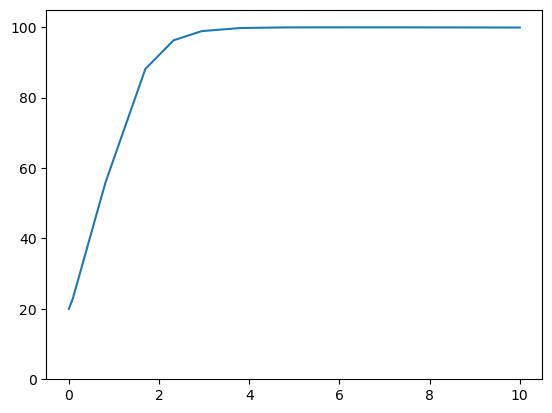

In [25]:
plt.plot(out.t, out.y[0])
plt.ylim(0, 105)
plt.show()

In [28]:
# specify evaluation points

t_array = np.linspace(0, 10, 100)

out2 = sint.solve_ivp(f, t_span, y0, t_eval=t_array)
out2

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  1.010e-01 ...  9.899e+00  1.000e+01]
        y: [[ 2.000e+01  2.343e+01 ...  9.992e+01  9.993e+01]]
      sol: None
 t_events: None
 y_events: None
     nfev: 68
     njev: 0
      nlu: 0

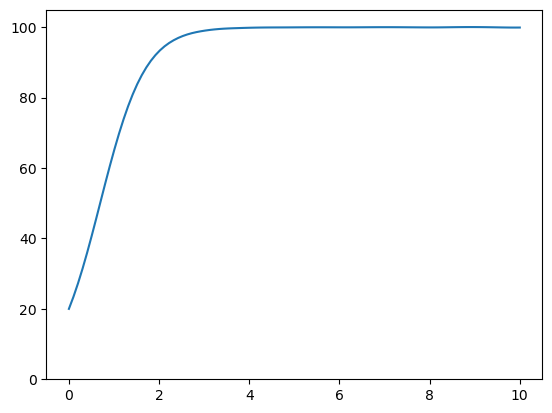

In [27]:
plt.plot(out2.t, out2.y[0])
plt.ylim(0, 105)
plt.show()

In [29]:
# request dense output

out3 = sint.solve_ivp(f, t_span, y0, dense_output=True)
out3

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  8.783e-02  8.117e-01  1.695e+00  2.322e+00
             2.949e+00  3.807e+00  4.835e+00  6.231e+00  8.135e+00
             1.000e+01]
        y: [[ 2.000e+01  2.296e+01  5.592e+01  8.814e+01  9.631e+01
              9.892e+01  9.979e+01  9.996e+01  9.999e+01  9.997e+01
              9.993e+01]]
      sol: <scipy.integrate._ivp.common.OdeSolution object at 0x0000024CBBED41A0>
 t_events: None
 y_events: None
     nfev: 68
     njev: 0
      nlu: 0

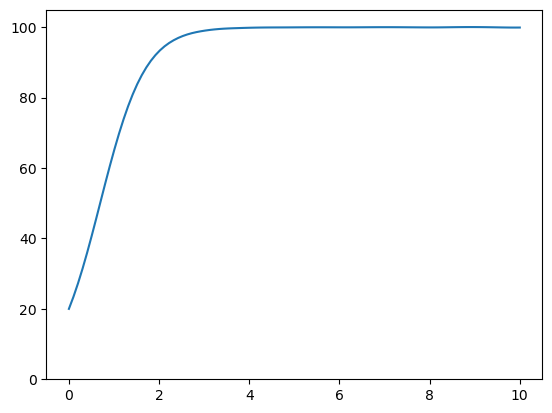

In [31]:
t_array = np.linspace(0, 10, 100)
P_array = out3.sol(t_array)[0]

plt.plot(t_array, P_array)
plt.ylim(0, 105)
plt.show()

## System of first-order differential equations

`scipy.integrate` is also capable of solving a system of first-order differential equations. Conceptually, all we are doing is to promote $y$ (and hence $\dot{y}$) from a scalar to a 1D array. As before, we need to put the system of equation into a standard form $\dot{\mathbf{y}} = \mathbf{f}(t, \mathbf{y})$. When $\mathbf{y}$ is 2-dimensional, this expands to:
\begin{align}
    \dot{y}_1 & = f_1(t, y_1, y_2) \\
    \dot{y}_2 & = f_2(t, y_1, y_2)
\end{align}

As an explicit example, consider the Lotka-Volterra Predator-Prey Model. The system is (with $x$ being prey and $y$ being predator):
\begin{align}
    \frac{dx}{dt} & = \alpha x - \beta x y \\
    \frac{dy}{dt} & = -\gamma y + \delta x y
\end{align}


In [32]:
def predator_prey(t, Y):
    return [
        alpha * Y[0] - beta * Y[0] * Y[1],
        -gamma * Y[1] + delta * Y[0] * Y[1]
    ]

alpha = 24
beta = 0.4
gamma = 2.0
delta = 0.002

In [34]:
t_span = [0, 5]
Y0 = [3000, 50]

out = sint.solve_ivp(predator_prey, t_span, Y0, dense_output=True)

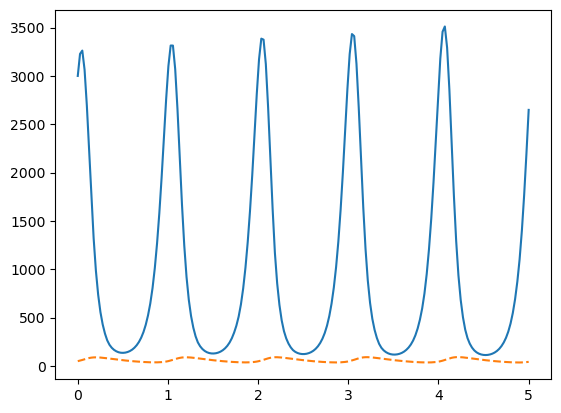

In [37]:
t_array = np.linspace(0, 5, 200)
Y_array = out.sol(t_array)

fig = plt.figure()
ax = fig.add_subplot()

ax.plot(t_array, Y_array[0], c="tab:blue", ls="-", label="prey")
ax.plot(t_array, Y_array[1], c="tab:orange", ls="--", label="predator")

plt.show(fig)

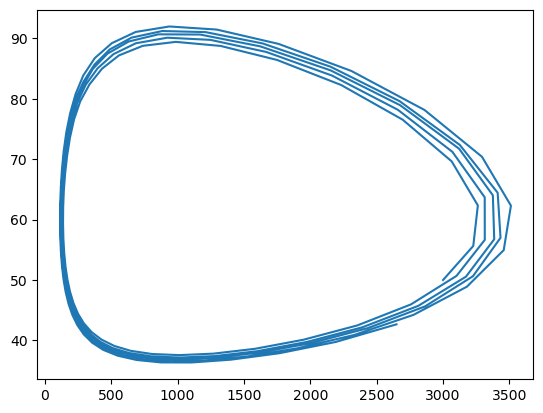

In [38]:
fig = plt.figure()
ax = fig.add_subplot()

ax.plot(Y_array[0], Y_array[1], c="tab:blue", ls="-", label="prey")

plt.show(fig)

In [40]:
# switch to an implicit solver
out2 = sint.solve_ivp(predator_prey, t_span, Y0, method="Radau", dense_output=True)

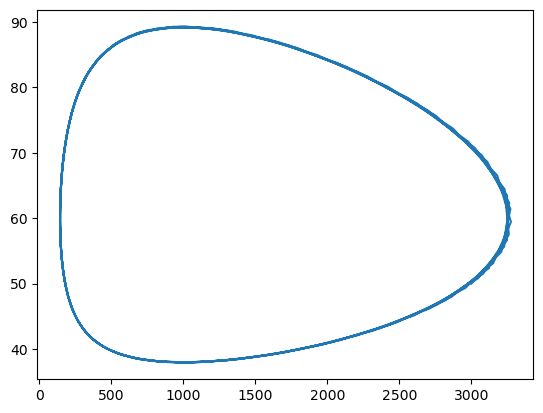

In [41]:
t_array = np.linspace(0, 5, 200)
Z_array = out2.sol(t_array)

fig = plt.figure()
ax = fig.add_subplot()

ax.plot(Z_array[0], Z_array[1], c="tab:blue", ls="-", label="prey")

plt.show(fig)